# Problem 2 (Regression)

- Import needed libraries
- import csv file and split it into 3 datasets [training , validation , testing]

In [70]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


df = pd.read_csv("California_Houses.csv")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]


calculate mean squared error and mean absolute erro

In [71]:
def mean_squared(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)


def mean_absolute(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


Normalize datasets , X = ( X - mean ) / standard deviation

In [72]:
means = train_df.mean(numeric_only=True)
stds = train_df.std(numeric_only=True)
train_norm = (train_df - means) / stds
val_norm = (val_df - means) / stds
test_norm = (test_df - means) / stds


Added Bias coloumn for datasets and dropped target coloumn

In [73]:
target_col = "Median_House_Value"   

X = train_norm.drop(columns=[target_col]).to_numpy()
V = val_norm.drop(columns=[target_col]).to_numpy()
Test = test_norm.drop(columns=[target_col]).to_numpy()

xones = np.ones((X.shape[0], 1))
vones = np.ones((V.shape[0], 1))
tones = np.ones((Test.shape[0], 1))

X_with_bias = np.hstack((xones, X))
v_with_bias = np.hstack((vones, V))
Test_with_bias = np.hstack((tones, Test))

x_target= train_norm[target_col].to_numpy().reshape(-1, 1)
v_target= val_norm[target_col].to_numpy().reshape(-1, 1)
t_target= test_norm[target_col].to_numpy().reshape(-1, 1)


# Manual Implementation

Calculate weights using Linear Regression - Direct form

In [74]:
W = np.dot(np.linalg.inv(np.dot(X_with_bias.T,X_with_bias)) ,np.dot(X_with_bias.T, x_target))
print("Closed-form solution Weights:")
print(W)

Closed-form solution Weights:
[[ 2.89325811e-15]
 [ 6.36005301e-01]
 [ 9.32457655e-02]
 [-8.58419773e-02]
 [ 3.35213599e-01]
 [-4.33752132e-01]
 [ 2.15762407e-01]
 [-8.29977015e-01]
 [-5.00022082e-01]
 [-9.81625567e-02]
 [-3.20338992e-01]
 [ 5.92475645e-01]
 [ 2.77901499e-01]
 [-2.68034666e-01]]


Test weights on validation dataset and calculate MSE and MAE

In [75]:
y_pred = np.dot(v_with_bias, W)
mse_lin_manual = mean_squared(v_target, y_pred)
mae_lin_manual = mean_absolute(v_target, y_pred)
print("Mean Squared Error (Validation):", mse_lin_manual)
print("Mean Absolute Error (Validation):", mae_lin_manual)

Mean Squared Error (Validation): 0.3442028256255914
Mean Absolute Error (Validation): 0.43155528201271687


Calculate weights using Linear Regression - Ridge regulization with different lambdas

In [76]:
print("\nRidge Regression with Different Lambdas:")
N = X_with_bias.shape[0]  
I = np.eye(X_with_bias.shape[1])  
lambdas = [0, 0.01, 0.1, 1, 10, 100]  

results1 = []
results2 = []
for lam in lambdas:
    W_Reg = np.dot(np.linalg.inv(np.dot(X_with_bias.T ,X_with_bias) + lam * N * I),np.dot(X_with_bias.T, x_target))
    y_pred = np.dot(v_with_bias , W_Reg)
    mse = mean_squared(v_target, y_pred)
    mae = mean_absolute(v_target, y_pred)
    results1.append((lam, mse))
    results2.append((lam, mae))
    print(f"Lambda = {lam}  |  Validation MSE = {mse}  |  Validation MAE = {mae}")
best_lambda, best_mse = min(results1, key=lambda x: x[1])
print("\nBest Lambda:", best_lambda)
print("Lowest Validation MSE:", best_mse)
best_lambda, best_mae = min(results2, key=lambda x: x[1])
print("\nBest Lambda:", best_lambda)
print("Lowest Validation MAE:", best_mae)
mse_ridge = best_mse
mae_ridge = best_mae


Ridge Regression with Different Lambdas:
Lambda = 0  |  Validation MSE = 0.3442028256255914  |  Validation MAE = 0.43155528201271687
Lambda = 0.01  |  Validation MSE = 0.34772534718235765  |  Validation MAE = 0.436341371579397
Lambda = 0.1  |  Validation MSE = 0.36487295462541686  |  Validation MAE = 0.4512349710417993
Lambda = 1  |  Validation MSE = 0.5029952548805287  |  Validation MAE = 0.5481162286536461
Lambda = 10  |  Validation MSE = 0.8564603662955038  |  Validation MAE = 0.7334596982006525
Lambda = 100  |  Validation MSE = 0.970154134782451  |  Validation MAE = 0.7814827053723533

Best Lambda: 0
Lowest Validation MSE: 0.3442028256255914

Best Lambda: 0
Lowest Validation MAE: 0.43155528201271687


graph for ridge regression

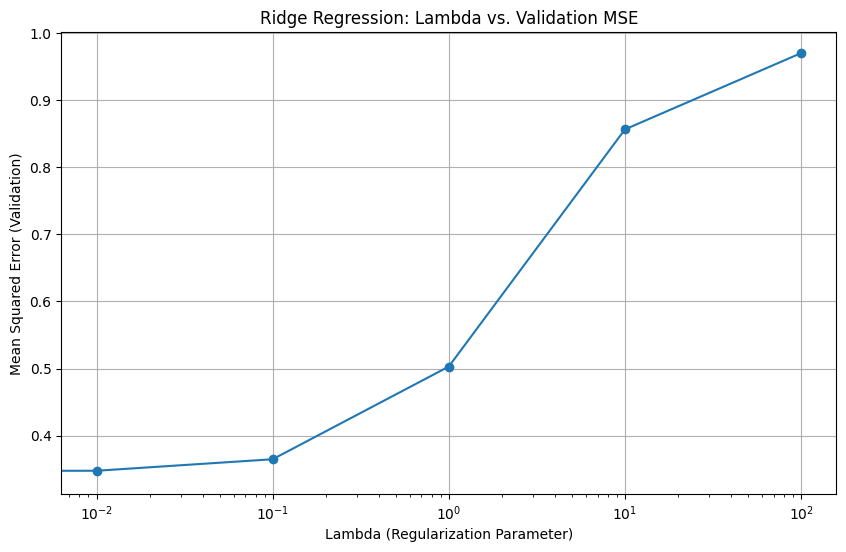

In [77]:
lambdas = [lam for lam, _ in results1]
mses = [mse for _, mse in results1]
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mses, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (Validation)')
plt.title('Ridge Regression: Lambda vs. Validation MSE')
plt.grid(True)
plt.show()

Calculate weights using Linear Regression - Gradient Descent

In [78]:
w = np.zeros((X_with_bias.shape[1],1))
learning_rate = 0.01
iterations = 1000
tolerance = 1e-6
prev_mse = float('inf')

for i in range(10000):
    y_pred = np.dot(v_with_bias, w)
    errors =  y_pred - v_target
    gradients = (1/N) * np.dot(v_with_bias.T, errors)
    w -= learning_rate * gradients

    current_mse = mean_squared(v_target, y_pred)
    if abs(prev_mse - current_mse) < tolerance:
        print(f"Converged after {i} iterations.")
        break
    prev_mse = current_mse
    
mae_lin_manual_gd = mean_absolute(v_target, y_pred)
print("Weights from Gradient Descent:\n", w)
print("Final MSE from Gradient Descent:", current_mse)
print("Final MAE from Gradient Descent:", mae_lin_manual_gd)
mse_lin_manual_gd = current_mse

Converged after 7728 iterations.
Weights from Gradient Descent:
 [[-0.00602444]
 [ 0.61558216]
 [ 0.11148987]
 [ 0.03848123]
 [ 0.24504839]
 [-0.40927901]
 [ 0.15177697]
 [-0.12191819]
 [-0.21211024]
 [-0.20367239]
 [-0.1971296 ]
 [-0.0041949 ]
 [-0.03224613]
 [-0.04273906]]
Final MSE from Gradient Descent: 0.35113767478940755
Final MAE from Gradient Descent: 0.43952386696476464


Calculate weights using Linear Regression - Ridge Regularization and Gradient Descent

In [79]:
N = X_with_bias.shape[0]
d = X_with_bias.shape[1]

learning_rate = 0.01
iterations = 10000
tolerance = 1e-6

lambdas = [0, 0.001, 0.01, 0.1, 1, 10]
results = []
best_w = None

for lam in lambdas:
    w = np.zeros((d, 1))
    prev_mse = float('inf')

    for i in range(iterations):
        y_pred = np.dot(v_with_bias, w)
        errors = y_pred - v_target
        gradients = (1/N) * (np.dot(v_with_bias.T, errors) + lam * w)
        w -= learning_rate * gradients
        current_mse = mean_squared(v_target, y_pred)
        if abs(prev_mse - current_mse) < tolerance:
            break
        prev_mse = current_mse

    mae = mean_absolute(v_target, y_pred)
    results.append((lam, current_mse, mae, w))
    print(f"Lambda = {lam:<6} | MSE = {current_mse:.6f} | MAE = {mae:.6f}")

best_lambda, best_mse, best_mae, best_w = min(results, key=lambda x: x[1])

print("\nBest Lambda:", best_lambda)
print("Lowest Validation MSE:", best_mse)
print("Corresponding MAE:", best_mae)
print("Best Weights:\n", best_w)

mse_ridge_gd = best_mse
mae_ridge_gd = best_mae


Lambda = 0      | MSE = 0.351138 | MAE = 0.439524
Lambda = 0.001  | MSE = 0.351138 | MAE = 0.439524
Lambda = 0.01   | MSE = 0.351138 | MAE = 0.439524
Lambda = 0.1    | MSE = 0.351141 | MAE = 0.439527
Lambda = 1      | MSE = 0.351171 | MAE = 0.439553
Lambda = 10     | MSE = 0.351477 | MAE = 0.439824

Best Lambda: 0
Lowest Validation MSE: 0.35113767478940755
Corresponding MAE: 0.43952386696476464
Best Weights:
 [[-0.00602444]
 [ 0.61558216]
 [ 0.11148987]
 [ 0.03848123]
 [ 0.24504839]
 [-0.40927901]
 [ 0.15177697]
 [-0.12191819]
 [-0.21211024]
 [-0.20367239]
 [-0.1971296 ]
 [-0.0041949 ]
 [-0.03224613]
 [-0.04273906]]


# Scikit-Learn Implementation

Calculate weights using Linear Regression

In [80]:
lin_model = LinearRegression()
lin_model.fit(X_with_bias, x_target)
y_pred_lin = lin_model.predict(v_with_bias)

mse_lin_scikit = mean_squared_error(v_target, y_pred_lin)
mae_lin_scikit = mean_absolute_error(v_target, y_pred_lin)

print("Linear Regression:")
print(f"  MSE = {mse_lin_scikit}")
print(f"  MAE = {mae_lin_scikit}")
print("-" * 40)

Linear Regression:
  MSE = 0.34420282562559146
  MAE = 0.43155528201271703
----------------------------------------


Calculate weights using Linear Regression - Lasso regulization

In [81]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_with_bias, x_target)
y_pred_lasso = lasso_model.predict(v_with_bias)

mse_lasso = mean_squared_error(v_target, y_pred_lasso)
mae_lasso = mean_absolute_error(v_target, y_pred_lasso)

print("Lasso Regression:")
print(f"  MSE = {mse_lasso}")
print(f"  MAE = {mae_lasso}")
print("-" * 40)

Lasso Regression:
  MSE = 0.4323996860504296
  MAE = 0.4927579716811169
----------------------------------------


Calculate weights using Linear Regression - Ridge regulization

In [82]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_with_bias, x_target)
y_pred_ridge = ridge_model.predict(v_with_bias)

mse_ridge_scikit = mean_squared_error(v_target, y_pred_ridge)
mae_ridge_scikit = mean_absolute_error(v_target, y_pred_ridge)

print("Ridge Regression:")
print(f"  MSE = {mse_ridge_scikit}")
print(f"  MAE = {mae_ridge_scikit}")
print("-" * 40)

Ridge Regression:
  MSE = 0.34424518306232615
  MAE = 0.43162576978101924
----------------------------------------


# Final Results Comparison

In [83]:
print("******Linear Regression******")
print("manual mse:", mse_lin_manual)
print("manual mae:", mae_lin_manual)
print("scikit mse:", mse_lin_scikit)
print("scikit mae:", mae_lin_scikit)
print("-" * 40)
print()

print("******Linear Regression (Gradient Descent)******")
print("manual mse (gd):", mse_lin_manual_gd)
print("manual mae (gd):", mae_lin_manual_gd)
print("-" * 40)
print()

print("******Ridge Regression******")
print("manual mse:", mse_ridge)
print("manual mae:", mae_ridge)
print("manual with gradient descent mse:", mse_ridge_gd)
print("manual with gradient descent mae:", mae_ridge_gd)
print("scikit mse:", mse_ridge_scikit)
print("scikit mae:", mae_ridge_scikit)
print("-" * 40)
print()

print("******Lasso Regression******")
print("scikit mse:", mse_lasso)
print("scikit mae:", mae_lasso)

******Linear Regression******
manual mse: 0.3442028256255914
manual mae: 0.43155528201271687
scikit mse: 0.34420282562559146
scikit mae: 0.43155528201271703
----------------------------------------

******Linear Regression (Gradient Descent)******
manual mse (gd): 0.35113767478940755
manual mae (gd): 0.43952386696476464
----------------------------------------

******Ridge Regression******
manual mse: 0.3442028256255914
manual mae: 0.43155528201271687
manual with gradient descent mse: 0.35113767478940755
manual with gradient descent mae: 0.43952386696476464
scikit mse: 0.34424518306232615
scikit mae: 0.43162576978101924
----------------------------------------

******Lasso Regression******
scikit mse: 0.4323996860504296
scikit mae: 0.4927579716811169


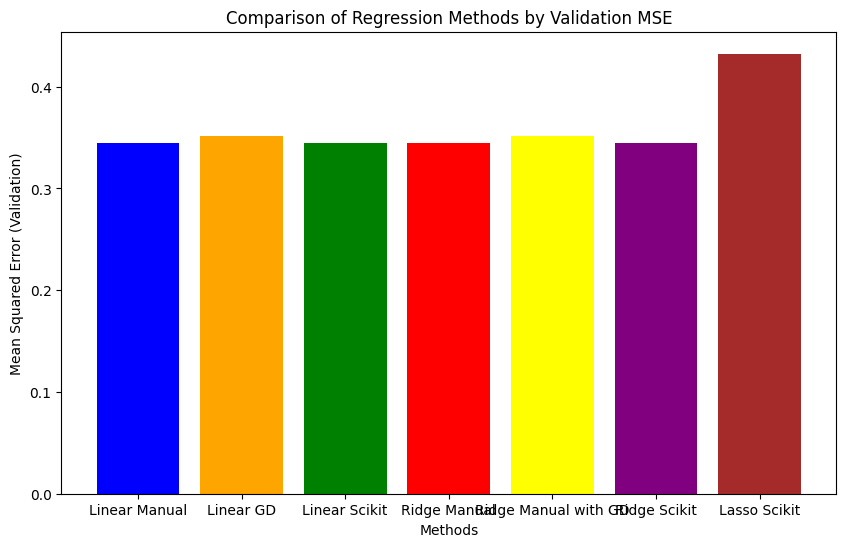

In [84]:
# graph for all methods
methods = ['Linear Manual', 'Linear GD', 'Linear Scikit', 'Ridge Manual','Ridge Manual with GD','Ridge Scikit', 'Lasso Scikit']
mses = [mse_lin_manual, mse_lin_manual_gd, mse_lin_scikit, mse_ridge, mse_ridge_gd,mse_ridge_scikit, mse_lasso]
plt.figure(figsize=(10, 6))
plt.bar(methods, mses, color=['blue', 'orange', 'green', 'red', 'yellow','purple', 'brown'])
plt.xlabel('Methods')
plt.ylabel('Mean Squared Error (Validation)')
plt.title('Comparison of Regression Methods by Validation MSE')
plt.show()